In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/student_performance.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6607
Number of columns: 20


In [5]:
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [7]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [10]:
print("Minimum Exam Score:", df["Exam_Score"].min())
print("Maximum Exam Score:", df["Exam_Score"].max())

Minimum Exam Score: 55
Maximum Exam Score: 101


In [11]:
df_clean = df.copy()

categorical_missing = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in categorical_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [12]:
print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Duplicate rows:", df_clean.duplicated().sum())

Rows before cleaning: 6607
Rows after cleaning: 6607
Duplicate rows: 0


In [13]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [14]:
print("Scores greater than 100:", (df["Exam_Score"] > 100).sum())

Scores greater than 100: 1


In [15]:
df["Exam_Score"].value_counts().sort_index().tail(15)

Exam_Score
86     4
87     2
88     3
89     3
91     1
92     2
93     2
94     4
95     2
96     1
97     3
98     3
99     2
100    1
101    1
Name: count, dtype: int64

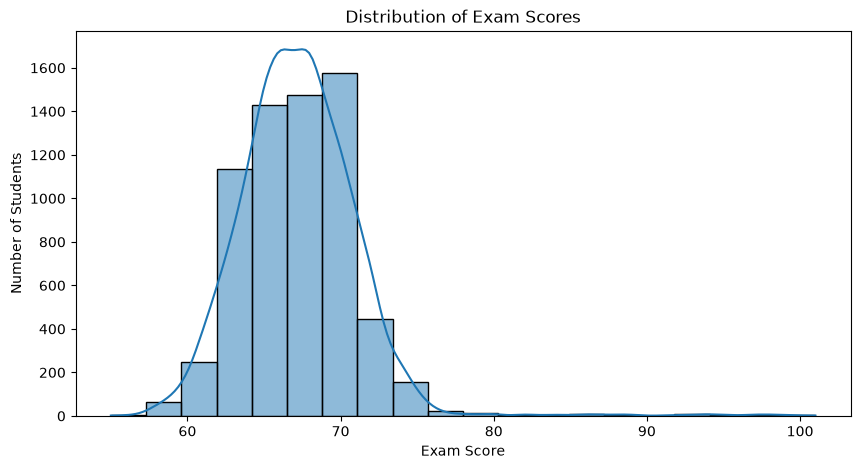

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

In [17]:
df_clean = df.copy()

df_clean["Exam_Score"] = df_clean["Exam_Score"].clip(upper=100)

print("Maximum score after correction:", df_clean["Exam_Score"].max())

Maximum score after correction: 100


In [18]:
categorical_missing = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in categorical_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(df_clean.isnull().sum().sum())

0


In [19]:
q1 = df_clean["Exam_Score"].quantile(0.25)
q3 = df_clean["Exam_Score"].quantile(0.75)

print("Low boundary:", q1)
print("High boundary:", q3)

Low boundary: 65.0
High boundary: 69.0


In [20]:
def performance_category(score):
    if score <= q1:
        return "Low"
    elif score <= q3:
        return "Average"
    else:
        return "High"

df_clean["Performance_Level"] = df_clean["Exam_Score"].apply(performance_category)

In [21]:
print(df_clean["Performance_Level"].value_counts())

Performance_Level
Average    2851
Low        2131
High       1625
Name: count, dtype: int64


In [22]:
print(df_clean["Performance_Level"].value_counts(normalize=True) * 100)

Performance_Level
Average    43.151203
Low        32.253670
High       24.595126
Name: proportion, dtype: float64


In [23]:
df_clean = df.copy()
df_clean["Exam_Score"] = df_clean["Exam_Score"].clip(upper=100)

print("Maximum score:", df_clean["Exam_Score"].max())

Maximum score: 100


In [24]:
categorical_missing = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in categorical_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


In [25]:
q1 = df_clean["Exam_Score"].quantile(0.25)
q3 = df_clean["Exam_Score"].quantile(0.75)

print("Low boundary:", q1)
print("High boundary:", q3)

Low boundary: 65.0
High boundary: 69.0


In [26]:
def performance_category(score):
    if score <= q1:
        return "Low"
    elif score <= q3:
        return "Average"
    else:
        return "High"

df_clean["Performance_Level"] = df_clean["Exam_Score"].apply(performance_category)

print(df_clean["Performance_Level"].value_counts())

Performance_Level
Average    2851
Low        2131
High       1625
Name: count, dtype: int64


In [27]:
X = df_clean.drop(columns=["Exam_Score", "Performance_Level"])
y = df_clean["Performance_Level"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [28]:
categorical_columns = X.select_dtypes(include=["object", "str"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Numerical columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


In [29]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (6607, 27)


In [30]:
X_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,1,0,0,0,...,1,1,0,1,0,1,0,0,1,1
1,19,64,8,59,2,4,1,0,0,1,...,1,1,0,0,0,0,0,1,0,0
2,24,98,7,91,2,4,0,1,0,1,...,1,1,1,0,0,0,1,0,1,1
3,29,89,8,98,1,4,1,0,0,1,...,1,1,0,0,0,1,0,1,0,1
4,19,92,6,65,3,4,0,1,0,1,...,0,1,1,0,0,0,0,0,1,0


In [31]:
print(X_encoded.dtypes.value_counts())

int64    27
Name: count, dtype: int64


In [32]:
X = df_clean.drop(columns=["Exam_Score", "Performance_Level"])
y = df_clean["Performance_Level"]

In [33]:
categorical_columns = X.select_dtypes(include=["object", "str"]).columns.tolist()

print(categorical_columns)

['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [34]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X_encoded.shape)

Shape after encoding: (6607, 27)


In [35]:
X_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,1,0,0,0,...,1,1,0,1,0,1,0,0,1,1
1,19,64,8,59,2,4,1,0,0,1,...,1,1,0,0,0,0,0,1,0,0
2,24,98,7,91,2,4,0,1,0,1,...,1,1,1,0,0,0,1,0,1,1
3,29,89,8,98,1,4,1,0,0,1,...,1,1,0,0,0,1,0,1,0,1
4,19,92,6,65,3,4,0,1,0,1,...,0,1,1,0,0,0,0,0,1,0


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5285, 27)
Testing features: (1322, 27)
Training target: (5285,)
Testing target: (1322,)


In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (5285, 27)
Scaled testing shape: (1322, 27)


In [40]:
print("First training row:")
print(X_train_scaled[0])

First training row:
[-1.49693911 -1.37810845 -1.37759902  0.19801287  0.41507745  0.99792233
 -0.50265944 -1.02393829 -0.49881713  0.99227205  0.81746251  1.57821195
 -1.01275878  0.28962084  1.20422683 -0.80975413 -0.3349079  -1.23543135
 -1.53270225  1.24230064 -0.81778463 -0.35042237 -1.00170439 -0.49822548
  1.53270225 -1.23543135  0.85536622]


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [42]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.9667170953101362


In [43]:
print("LOGISTIC REGRESSION")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("Precision:",
      precision_score(y_test, y_pred_logistic, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_logistic, average="weighted"))

print("F1 Score:",
      f1_score(y_test, y_pred_logistic, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

LOGISTIC REGRESSION
Accuracy: 0.9667170953101362
Precision: 0.967034458198311
Recall: 0.9667170953101362
F1 Score: 0.966705589378618

Classification Report:
              precision    recall  f1-score   support

     Average       0.95      0.98      0.96       571
        High       0.98      0.94      0.96       325
         Low       0.98      0.97      0.97       426

    accuracy                           0.97      1322
   macro avg       0.97      0.96      0.97      1322
weighted avg       0.97      0.97      0.97      1322



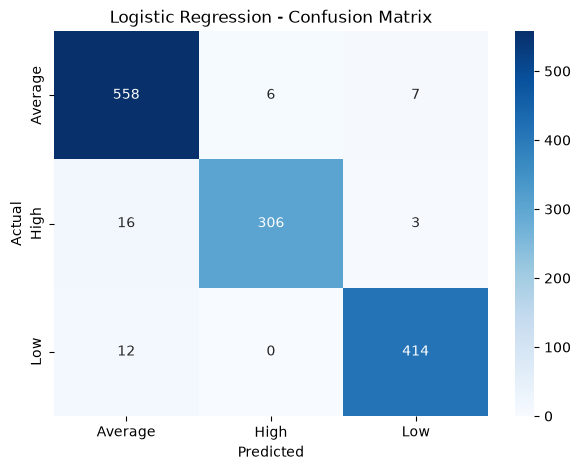

In [44]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Average", "High", "Low"],
    yticklabels=["Average", "High", "Low"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

decision_tree.fit(X_train_scaled, y_train)

y_pred_tree = decision_tree.predict(X_test_scaled)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7322239031770046


In [46]:
print("DECISION TREE")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("Precision:",
      precision_score(y_test, y_pred_tree, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_tree, average="weighted"))

print("F1 Score:",
      f1_score(y_test, y_pred_tree, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

DECISION TREE
Accuracy: 0.7322239031770046
Precision: 0.7431779402103948
Recall: 0.7322239031770046
F1 Score: 0.732994626538511

Classification Report:
              precision    recall  f1-score   support

     Average       0.66      0.79      0.72       571
        High       0.76      0.64      0.69       325
         Low       0.84      0.73      0.78       426

    accuracy                           0.73      1322
   macro avg       0.75      0.72      0.73      1322
weighted avg       0.74      0.73      0.73      1322



In [47]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

random_forest.fit(X_train_scaled, y_train)

y_pred_rf = random_forest.predict(X_test_scaled)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8199697428139183


In [48]:
print("RANDOM FOREST")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_rf, average="weighted"))

print("F1 Score:",
      f1_score(y_test, y_pred_rf, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy: 0.8199697428139183
Precision: 0.8379653257331997
Recall: 0.8199697428139183
F1 Score: 0.8198829358797729

Classification Report:
              precision    recall  f1-score   support

     Average       0.74      0.91      0.82       571
        High       0.91      0.70      0.79       325
         Low       0.92      0.79      0.85       426

    accuracy                           0.82      1322
   macro avg       0.86      0.80      0.82      1322
weighted avg       0.84      0.82      0.82      1322



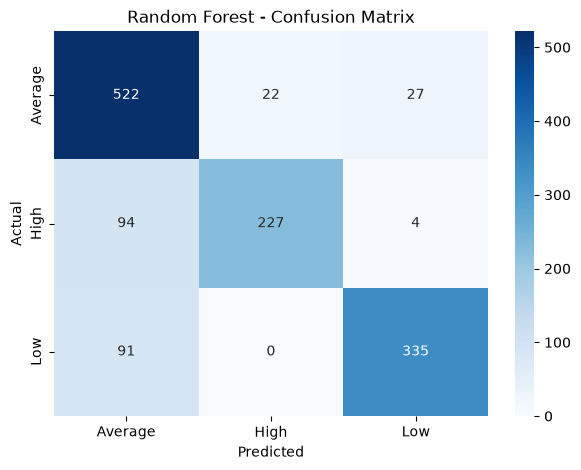

In [49]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Average", "High", "Low"],
    yticklabels=["Average", "High", "Low"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train_scaled, y_train)

y_pred_gb = gradient_boosting.predict(X_test_scaled)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8381240544629349


In [51]:
print("GRADIENT BOOSTING")
print("=" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("Precision:",
      precision_score(y_test, y_pred_gb, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_gb, average="weighted"))

print("F1 Score:",
      f1_score(y_test, y_pred_gb, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

GRADIENT BOOSTING
Accuracy: 0.8381240544629349
Precision: 0.8433423769651348
Recall: 0.8381240544629349
F1 Score: 0.8386041814621962

Classification Report:
              precision    recall  f1-score   support

     Average       0.78      0.87      0.83       571
        High       0.88      0.79      0.83       325
         Low       0.89      0.83      0.86       426

    accuracy                           0.84      1322
   macro avg       0.85      0.83      0.84      1322
weighted avg       0.84      0.84      0.84      1322



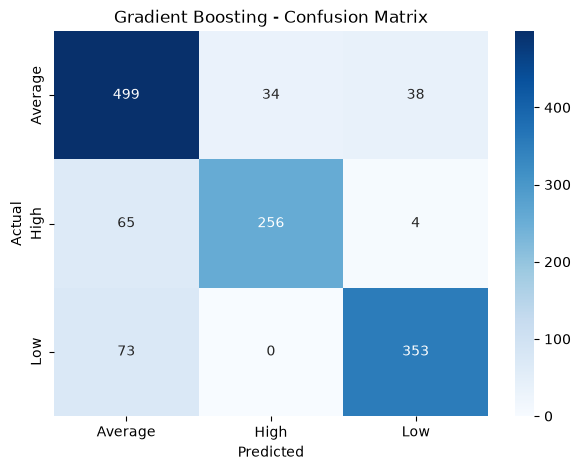

In [52]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Average", "High", "Low"],
    yticklabels=["Average", "High", "Low"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_logistic, average="weighted"),
        precision_score(y_test, y_pred_tree, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_gb, average="weighted")
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_logistic, average="weighted"),
        recall_score(y_test, y_pred_tree, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_gb, average="weighted")
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_logistic, average="weighted"),
        f1_score(y_test, y_pred_tree, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_gb, average="weighted")
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.966717,0.967034,0.966717,0.966706
1,Decision Tree,0.732224,0.743178,0.732224,0.732995
2,Random Forest,0.819970,0.837965,0.819970,0.819883
3,Gradient Boosting,0.838124,0.843342,0.838124,0.838604


In [54]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                0.966717
Precision               0.967034
Recall                  0.966717
F1 Score                0.966706
Name: 0, dtype: object


In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Attendance,0.365231
0,Hours_Studied,0.212810
3,Previous_Scores,0.083664
4,Tutoring_Sessions,0.040739
2,Sleep_Hours,0.029891
5,Physical_Activity,0.026427
8,Access_to_Resources_Low,0.019865
6,Parental_Involvement_Low,0.018274
14,Family_Income_Low,0.014620
20,Peer_Influence_Positive,0.013899


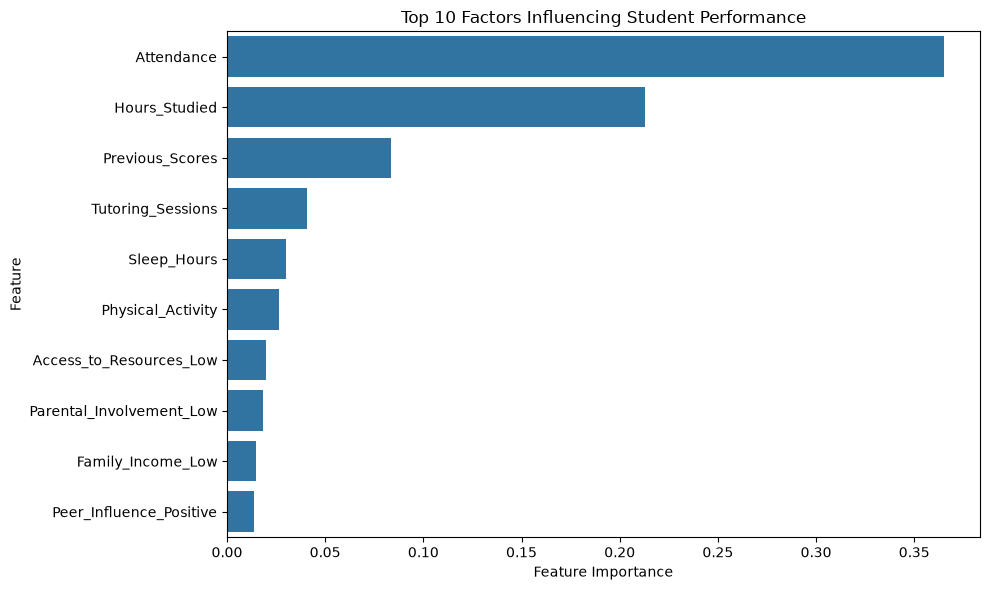

In [56]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Factors Influencing Student Performance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

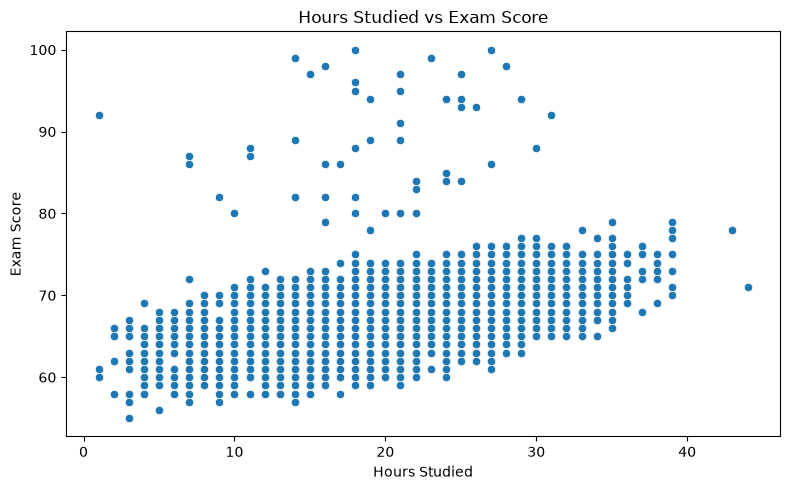

In [57]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

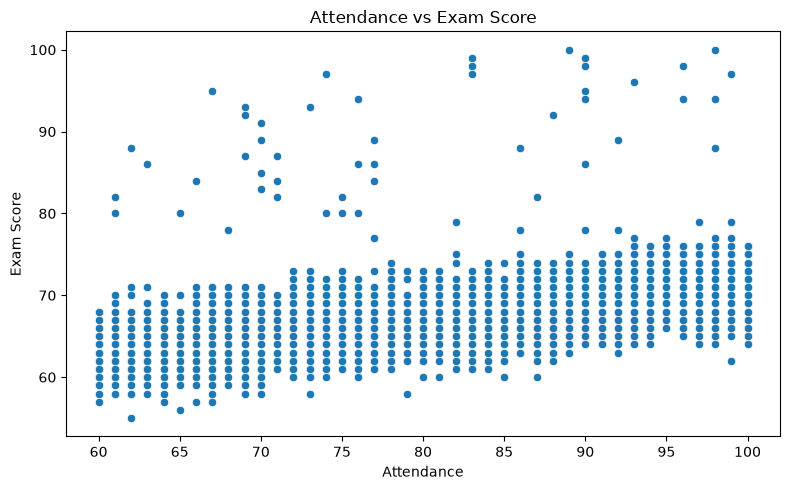

In [58]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

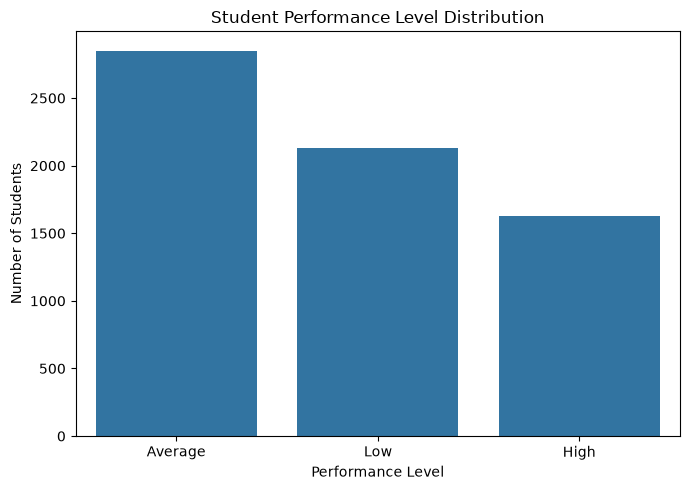

In [59]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Performance_Level"
)

plt.title("Student Performance Level Distribution")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

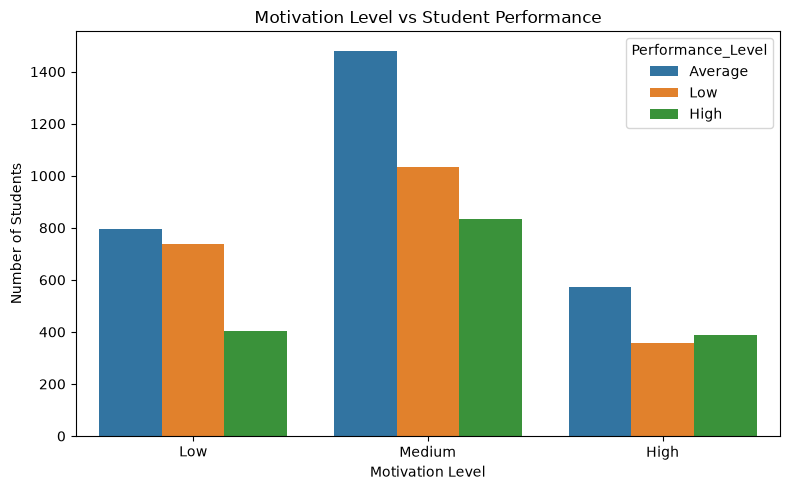

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Motivation_Level",
    hue="Performance_Level"
)

plt.title("Motivation Level vs Student Performance")
plt.xlabel("Motivation Level")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

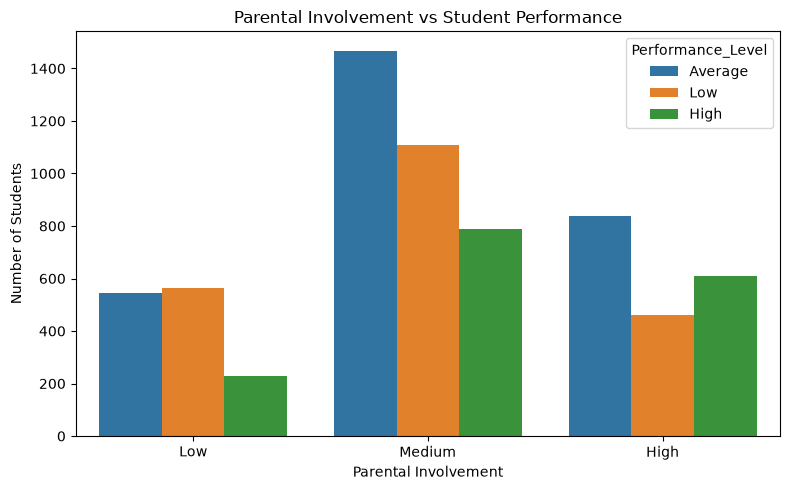

In [61]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Parental_Involvement",
    hue="Performance_Level"
)

plt.title("Parental Involvement vs Student Performance")
plt.xlabel("Parental Involvement")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

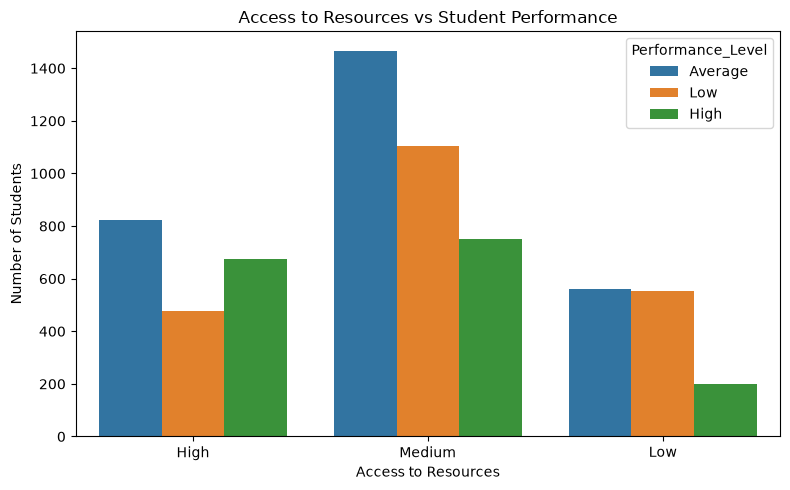

In [62]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Access_to_Resources",
    hue="Performance_Level"
)

plt.title("Access to Resources vs Student Performance")
plt.xlabel("Access to Resources")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

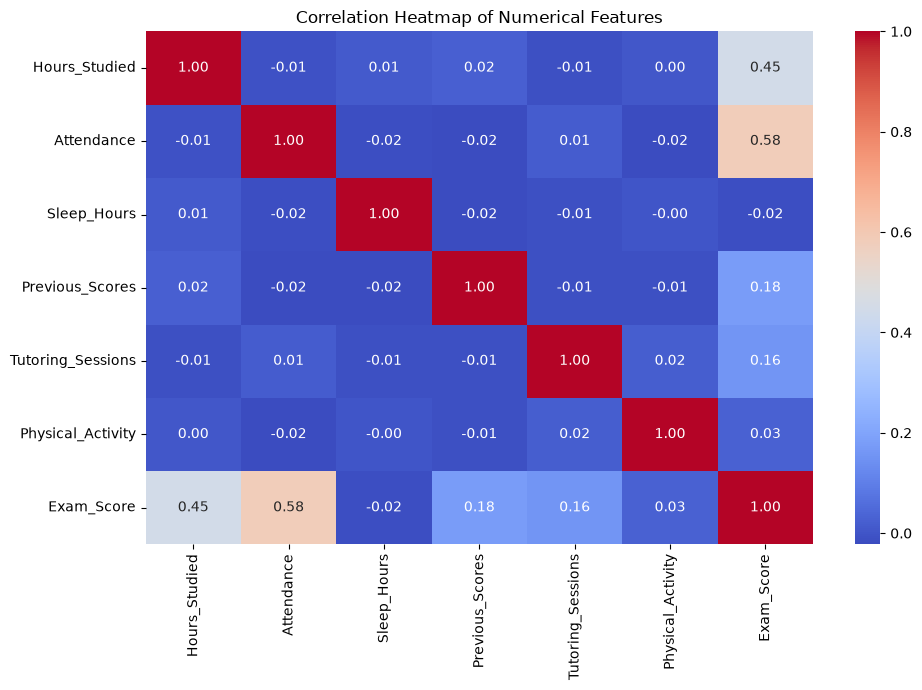

In [63]:
numerical_data = df_clean.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))

sns.heatmap(
    numerical_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [64]:
feature_importance.to_csv(
    "../report/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [65]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.966717,0.967034,0.966717,0.966706
1,Decision Tree,0.732224,0.743178,0.732224,0.732995
2,Random Forest,0.819970,0.837965,0.819970,0.819883
3,Gradient Boosting,0.838124,0.843342,0.838124,0.838604


In [66]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [67]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Decision Tree":
    best_model = decision_tree

elif best_model_name == "Random Forest":
    best_model = random_forest

elif best_model_name == "Gradient Boosting":
    best_model = gradient_boosting

print("Selected model:", best_model_name)

Selected model: Logistic Regression


In [68]:
final_predictions = best_model.predict(X_test_scaled)

print("Final Accuracy:",
      accuracy_score(y_test, final_predictions))

print("\nFinal Classification Report:")
print(classification_report(y_test, final_predictions))

Final Accuracy: 0.9667170953101362

Final Classification Report:
              precision    recall  f1-score   support

     Average       0.95      0.98      0.96       571
        High       0.98      0.94      0.96       325
         Low       0.98      0.97      0.97       426

    accuracy                           0.97      1322
   macro avg       0.97      0.96      0.97      1322
weighted avg       0.97      0.97      0.97      1322



In [69]:
import joblib

In [70]:
joblib.dump(
    best_model,
    "../models/student_performance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [71]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [72]:
joblib.dump(
    X_encoded.columns.tolist(),
    "../models/feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [73]:
import os

print("Model exists:",
      os.path.exists("../models/student_performance_model.pkl"))

print("Scaler exists:",
      os.path.exists("../models/scaler.pkl"))

print("Feature names exist:",
      os.path.exists("../models/feature_names.pkl"))

Model exists: True
Scaler exists: True
Feature names exist: True
